# Assignment 3

## Statement of AI usage
AI (ChatGPT and Claude) has been used to help with troubleshooting code throughout the assignment. AI has also been used to help develop the prompts, as the weaker model had some serious trouble with following the instructions.


## Task 0

**a) and b)**

In [1]:
from openai import OpenAI

client = OpenAI(
    base_url='http://localhost:11434/v1/',
    api_key='ollama',  )

chat_completion = client.chat.completions.create(
    messages=[
        {
            'role': 'user',
            'content': 'Who is the most likely English Premier League winner during the season 2025-2026?',
        }
    ],
    model='gemma3:270m',
)
print(chat_completion.choices[0].message.content)

The most likely English Premier League winner during the season 2025-2026 is **England**.



**c)**

In [2]:
client = OpenAI(
    base_url='http://localhost:11434/v1/',
    api_key='ollama',  
)

chat_completion = client.chat.completions.create(
    messages=[
        {
            'role': 'user',
            'content': 'Who is the most likely English Premier League winner during the season 2025-2026?',
        }
    ],
    model='gemma3:4b',
)
print(chat_completion.choices[0].message.content)

Okay, let's break down the most likely Premier League winner for the 2025-26 season. This is purely speculative, of course, but based on current trends, squad strength, and potential investments, **Manchester City are still the overwhelming favorites.**

Here's a breakdown of why, and some contenders:

**1. Manchester City (Highly Likely - 60-70% Probability):**

* **Why:** They're the current champions, have arguably the best squad currently, and a ridiculously astute manager in Pep Guardiola.  They’ve invested heavily in their core and have a phenomenal track record of improvement.
* **Strengths:** Dominant midfield (De Bruyne, Rodri, potentially a new signing), Erling Haaland (world-class striker), a defensively solid unit, and tactical brilliance.
* **Weaknesses:** They can be prone to dips in form and rely heavily on Guardiola’s management. 

**2. Arsenal (Strong Contender - 20-30% Probability):**

* **Why:** Arsenal have been consistently strong over the last few seasons and have

## Task 1

In [3]:
import pandas as pd

df_emails = pd.read_csv("/Users/felix/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/Python4BusinessInt/Assignments/data/emails.csv", sep="\t", engine="python")

df_emails = pd.DataFrame(df_emails)
df_emails

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review
5,"Q3 budget report attached, please review by Fr..."
6,Reminder: Annual performance review scheduled ...
7,"Updated draft of the manuscript, comments welcome"
8,Quick question about last week
9,Following up


**a)**

In [4]:
def analyse_emails(text, model):
    prompt = (
        "Classify the email headline below into exactly one of these three categories: Spam, Work, Unknown. "
        "Rules: "
        "- Return only the single word classification. "
        "- Do not explain, do not add punctuation, do not add anything else. "
        "- If unsure, return Unknown. "
        f"Headline: {text} "
        "Classification:"
    )
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    result = response.choices[0].message.content.strip()
    return result if result in {"Spam", "Work", "Unknown"} else "Unknown" #Had to add a "fail-safe", as the weaker model had some serious trouble following the instructions.


**b)**

In [5]:
df_emails["category"] = df_emails["headline"].apply(analyse_emails, model = "gemma3:270m")
df_emails

,headline,category
0,URGENT: Your account will be suspended within ...,Unknown
1,Congratulations! You have won a 1000€ gift car...,Spam
2,Hot singles in your area are waiting to meet y...,Spam
3,Re: Inheritance transfer of 4.5M USD pending y...,Unknown
4,Meeting agenda for Thursday's project review,Unknown
5,"Q3 budget report attached, please review by Fr...",Spam
6,Reminder: Annual performance review scheduled ...,Spam
7,"Updated draft of the manuscript, comments welcome",Spam
8,Quick question about last week,Unknown
9,Following up,Spam


**c)**

In [6]:
df_emails["category"] = df_emails["headline"].apply(analyse_emails, model = "gemma3:4b")
df_emails

,headline,category
0,URGENT: Your account will be suspended within ...,Spam
1,Congratulations! You have won a 1000€ gift car...,Spam
2,Hot singles in your area are waiting to meet y...,Spam
3,Re: Inheritance transfer of 4.5M USD pending y...,Work
4,Meeting agenda for Thursday's project review,Work
5,"Q3 budget report attached, please review by Fr...",Work
6,Reminder: Annual performance review scheduled ...,Work
7,"Updated draft of the manuscript, comments welcome",Work
8,Quick question about last week,Unknown
9,Following up,Unknown


**Comment:** The weaker (gemma3:270m) model doesn't classify a single email as "work", whereas the stronger model seems to do a pretty good job of classifying the emails.

**d)**

In [7]:
results_df = df_emails[["headline"]].copy()
models = ["gemma3:270m", "gemma3:4b"]

for model in models:
    for run in range(1, 4):
        col_name = f"{model.replace(':', '_')}_run_{run}"
        results_df[col_name] = df_emails["headline"].apply(analyse_emails, model=model)

results_df

,headline,gemma3_270m_run_1,gemma3_270m_run_2,gemma3_270m_run_3,gemma3_4b_run_1,gemma3_4b_run_2,gemma3_4b_run_3
0,URGENT: Your account will be suspended within ...,Spam,Unknown,Unknown,Spam,Spam,Spam
1,Congratulations! You have won a 1000€ gift car...,Spam,Spam,Spam,Spam,Spam,Spam
2,Hot singles in your area are waiting to meet y...,Spam,Spam,Spam,Spam,Spam,Spam
3,Re: Inheritance transfer of 4.5M USD pending y...,Unknown,Spam,Unknown,Work,Work,Work
4,Meeting agenda for Thursday's project review,Spam,Spam,Unknown,Work,Work,Work
5,"Q3 budget report attached, please review by Fr...",Spam,Spam,Unknown,Work,Work,Work
6,Reminder: Annual performance review scheduled ...,Spam,Spam,Spam,Work,Work,Work
7,"Updated draft of the manuscript, comments welcome",Spam,Unknown,Spam,Work,Work,Work
8,Quick question about last week,Spam,Unknown,Unknown,Unknown,Unknown,Unknown
9,Following up,Spam,Spam,Spam,Unknown,Unknown,Unknown


**Comment:** The result are as one might expect: the weaker model is very uncertain of its classifications which leads to a lot of variation in the results, whereas the stronger model handles the task a lot better, it is able to follow the instructions constantly and there is no variation in the results. 

**Task 2**

In [8]:
df_news = pd.read_csv("/Users/felix/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/Python4BusinessInt/Assignments/data/news.csv", sep="\t", engine="python")
df_news

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...
5,Kestrel Semiconductor confirms early-stage mer...
6,New EU AI Act compliance rules expected to rai...
7,Finnish FSA grants Norvik Capital expanded lic...
8,"Eurozone inflation cools to 2.1%, easing press..."
9,Rising interest rates weigh on Tessaro Real Es...


**a)**

In [9]:
def ask_llm(prompt):
    response = client.chat.completions.create(
        model='gemma3:4b',
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

def news_classification(text):
    prompt = (f"""To each headline assign one of the following categories: earnings, mergers, regulation, macroeconomics. 
              For each headline, determine the sentiment and assign one of the following: positive, negative, neutral.
              Return only valid JSON in this exact format:{{"topic": "earnings", "sentiment": "positive"}}
            Headline:{text}"""
             )
    result = ask_llm(prompt).strip()
    result = result.replace("```json", "").replace("```", "").strip()
    return json.loads(result)

**b)**

In [10]:
results_df = df_news[["headline"]].copy()

classified = results_df["headline"].apply(news_classification)

classified_df = pd.DataFrame(classified.tolist())

results_df = pd.concat([results_df, classified_df], axis=1)

results_df

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,neutral
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,neutral
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


**c)**

| headline | category | sentiment |
|---|---|---|
| Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | earnings | positive |
| Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | earnings | negative |
| Aurelis Bank reports steady quarterly profit, in line with analyst expectations | earnings | neutral |
| Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | mergers | neutral |
| Antitrust regulators block proposed merger between Solenta and Marvex Energy | mergers | negative |
| Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | mergers | neutral |
| New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | regulation | negative |
| Finnish FSA grants Norvik Capital expanded licence for cross-border operations | regulation | positive |
| Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | macroeconomics | positive |
| Rising interest rates weigh on Tessaro Real Estate as financing costs climb | macroeconomics | negative |

**Comment:** I gave this task to ChatGpt 5.5. For the most part, the results are the same. The category classification only differs on one occasion (headline 4), but in the sentiment there is a lot of variation between 'neutral' and 'positive'. In my opinion, ChatGpt performs better and is able to understand the sentiments better. For example, take headline 2: gemma3:4b labels it as positive, whereas ChatGpt labels it as neutral. The headline however implies something that is already expected, and hence ChatGpts 'neutral' is more accurate. The same logic can be applied to the rest of the headlines that differ. 

**Task 3**

In [11]:
df = pd.read_csv("/Users/felix/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/Python4BusinessInt/Assignments/data/bank-additional.csv", sep =";" )
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


**a)**

In [12]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

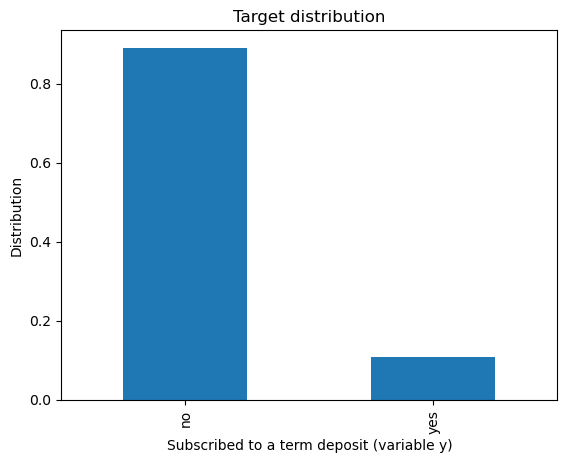

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
df["y"].value_counts(normalize=True).plot(kind="bar")
plt.title("Target distribution")
plt.ylabel("Distribution")
plt.xlabel("Subscribed to a term deposit (variable y)")
plt.show()

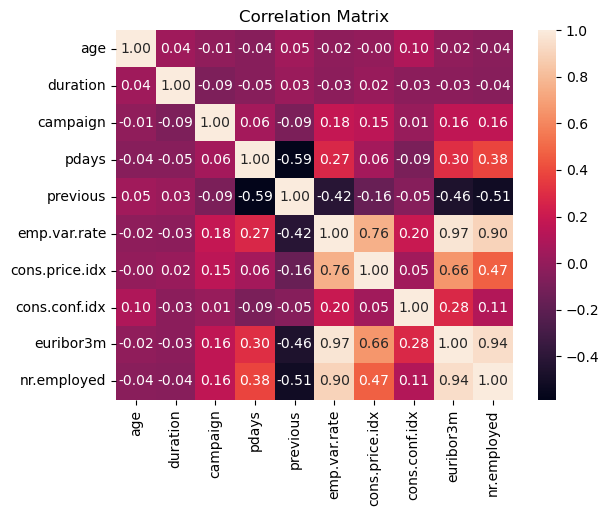

In [15]:
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

**b)**

In [16]:
df["y"] = df["y"].map({"no": 0, "yes": 1})

X = df.drop("y", axis=1)
y = df["y"]



In [17]:
#standardization of numerical variables and creating numerical dummies for categorical variables.
from sklearn.preprocessing import StandardScaler, LabelEncoder

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = X.select_dtypes(include=["object"]).columns

scaler = StandardScaler()

X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

label_encoders = {}

for col in categorical_cols:
    
    le = LabelEncoder()
    
    X[col] = le.fit_transform(X[col])
    
    label_encoders[col] = le

X.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,-0.980752,1,1,2,0,2,0,0,6,0,0.903952,-0.209228,0.201031,-0.351356,1,-1.206054,-1.185448,-1.240939,-1.331707,-0.914779
1,-0.107991,7,2,3,0,0,0,1,6,0,0.350300,0.569634,0.201031,-0.351356,1,0.649441,0.715193,0.892269,0.711698,0.332862
2,-1.465619,7,1,3,0,2,0,1,4,4,-0.116966,-0.598660,0.201031,-0.351356,1,0.841389,1.528273,-0.283172,0.773427,0.836535
3,-0.204965,7,1,2,0,1,1,1,4,0,-0.941553,0.180203,0.201031,-0.351356,1,0.841389,1.528273,-0.283172,0.771697,0.836535
4,0.667795,0,1,6,0,2,0,0,7,1,-0.780563,-0.598660,0.201031,-0.351356,1,-0.118350,-0.655478,-0.326707,0.328632,0.398028


**c)**

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nClass balance (train):")
print(y_train.value_counts())
print("\nClass balance (test):")
print(y_test.value_counts())

Train set size: 3295
Test set size: 824

Class balance (train):
y
0    2936
1     359
Name: count, dtype: int64

Class balance (test):
y
0    732
1     92
Name: count, dtype: int64


This is a classification task. I've chosen to proceed with the following models:

Logistic regression: Gives a basic, strong baseline.

Random forest: A highly robust model that isn't sensitive to outliers and is expected to have a high performance due to its variance reducing capabilities. 

Support Vector Machine (SVM): A very common tool for classification tasks due to its strong classification capabilities, making it a clear choice for this task. Likewise as the RF, SVM is not sensitive to outliers and in addition, less prone to overfitting.

In [19]:
# First split: 80/20 into train+val and test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Second split: 75/25 of the 80% into train and validation (0.75 * 0.8 = 0.6, 0.25 * 0.8 = 0.2)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print("Train set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])
print("\nClass balance (train):")
print(y_train.value_counts())

Train set size: 2471
Validation set size: 824
Test set size: 824

Class balance (train):
y
0    2206
1     265
Name: count, dtype: int64


In [20]:
#Training SVM
from sklearn.svm import SVC

svm_model = SVC(random_state=42, class_weight="balanced")
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_val)

In [21]:
#Training Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

In [22]:
#Training logistic regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_val)

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for name, y_pred in [("SVM", y_pred_svm), ("Random Forest", y_pred_rf), ("Logistic Regression", y_pred_log)]:
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_val, y_pred):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred):.4f}")
    print()

--- SVM ---
Accuracy:  0.8580
Precision: 0.4392
Recall:    0.8830
F1-score:  0.5866

--- Random Forest ---
Accuracy:  0.9078
Precision: 0.6607
Recall:    0.3936
F1-score:  0.4933

--- Logistic Regression ---
Accuracy:  0.9138
Precision: 0.7447
Recall:    0.3723
F1-score:  0.4965



In [24]:
#adjusting the parameters

In [25]:
#try n. 1
lr  = LogisticRegression(C=10, class_weight="balanced", max_iter=1000, random_state=42)
svm = SVC(C=10, gamma="scale", kernel="rbf", class_weight="balanced", random_state=42)
rf  = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight="balanced", random_state=42)

lr.fit(X_train, y_train)
print("LR: ", f"{recall_score(y_val, lr.predict(X_val)):.4f}")

svm.fit(X_train, y_train)
print("SVM:", f"{recall_score(y_val, svm.predict(X_val)):.4f}")

rf.fit(X_train, y_train)
print("RF: ", f"{recall_score(y_val, rf.predict(X_val)):.4f}")

LR:  0.8936
SVM: 0.7553
RF:  0.8830


In [26]:
#final
best_lr  = LogisticRegression(C=10, class_weight="balanced", max_iter=1000, random_state=42)
best_svm = SVC(C=1, gamma="scale", kernel="rbf", class_weight="balanced", random_state=42)
best_rf  = RandomForestClassifier(n_estimators=100, max_depth=10, bootstrap=False, class_weight="balanced", random_state=42)

best_lr.fit(X_train, y_train)
print("LR: ", f"{recall_score(y_val, lr.predict(X_val)):.4f}")

best_svm.fit(X_train, y_train)
print("SVM:", f"{recall_score(y_val, svm.predict(X_val)):.4f}")

best_rf.fit(X_train, y_train)
print("RF: ", f"{recall_score(y_val, rf.predict(X_val)):.4f}")

LR:  0.8936
SVM: 0.7553
RF:  0.8830


**d)**

In [27]:
#GridSearch for SVM hyperparameters
from sklearn.model_selection import GridSearchCV
param_grid_svm = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1],
    "kernel": ["rbf"]
}
grid_svm = GridSearchCV(SVC(random_state=42, class_weight="balanced"), param_grid_svm, cv=5, scoring="recall", n_jobs=-1)
grid_svm.fit(X_train, y_train)
print("Best SVM parameters:", grid_svm.best_params_)
print("Best SVM Recall (CV):", f"{grid_svm.best_score_:.4f}")
# Evaluate on validation set
y_pred_svm_tuned = grid_svm.best_estimator_.predict(X_val)
print("Validation Recall:", f"{recall_score(y_val, y_pred_svm_tuned):.4f}")

Best SVM parameters: {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
Best SVM Recall (CV): 0.8717
Validation Recall: 0.8404


In [28]:
#GridSearch for Random Forest hyperparameters
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "bootstrap": [True, False]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"), param_grid_rf, cv=5, scoring="recall", n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best RF parameters:", grid_rf.best_params_)
print("Best RF Recall (CV):", f"{grid_rf.best_score_:.4f}")

# Evaluate on validation set
y_pred_rf_tuned = grid_rf.best_estimator_.predict(X_val)
print("Validation Recall:", f"{recall_score(y_val, y_pred_rf_tuned):.4f}")

Best RF parameters: {'bootstrap': False, 'max_depth': 5, 'n_estimators': 300}
Best RF Recall (CV): 0.8906
Validation Recall: 0.8830


In [29]:
#GridSearch for Logistic Regressin hyperparameters
param_grid_log = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"]
}

grid_log = GridSearchCV(estimator=log_model, param_grid= param_grid_log,cv=5,scoring="f1",n_jobs=-1)

grid_log.fit(X_train, y_train)

print("Best LR parameters:", grid_log.best_params_)
print("Best LR Recall (CV):", f"{grid_log.best_score_:.4f}")

# Evaluate on validation set
y_pred_LR_tuned = grid_log.best_estimator_.predict(X_val)
print("Validation Recall:", f"{recall_score(y_val, y_pred_LR_tuned):.4f}")

Best LR parameters: {'C': 10, 'class_weight': 'balanced'}
Best LR Recall (CV): 0.5777
Validation Recall: 0.8936


In [30]:
print("LR  — Split:", f"{recall_score(y_test, best_lr.predict(X_test)):.4f}",  "| CV:", f"{recall_score(y_test, grid_log.best_estimator_.predict(X_test)):.4f}")
print("SVM — Split:", f"{recall_score(y_test, best_svm.predict(X_test)):.4f}", "| CV:", f"{recall_score(y_test, grid_svm.best_estimator_.predict(X_test)):.4f}")
print("RF  — Split:", f"{recall_score(y_test, best_rf.predict(X_test)):.4f}",  "| CV:", f"{recall_score(y_test, grid_rf.best_estimator_.predict(X_test)):.4f}")

LR  — Split: 0.8587 | CV: 0.8587
SVM — Split: 0.8370 | CV: 0.8913
RF  — Split: 0.6413 | CV: 0.8587


According to the results, CV performs a lot better.

**e)**

In [31]:
y_test_svm = grid_svm.best_estimator_.predict(X_test)

print("--- Final SVM (Test Set) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_test_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_test_svm):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_svm):.4f}")
print(f"F1-score:  {f1_score(y_test, y_test_svm):.4f}")

--- Final SVM (Test Set) ---
Accuracy:  0.7743
Precision: 0.3178
Recall:    0.8913
F1-score:  0.4686


In [32]:
y_test_rf = grid_rf.best_estimator_.predict(X_test)

print("--- Final Random Forest (Test Set) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_test_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_test_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_rf):.4f}")
print(f"F1-score:  {f1_score(y_test, y_test_rf):.4f}")

--- Final Random Forest (Test Set) ---
Accuracy:  0.8398
Precision: 0.3990
Recall:    0.8587
F1-score:  0.5448


In [33]:
y_test_log = grid_log.best_estimator_.predict(X_test)

print("--- Final SVM (Test Set) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_test_log):.4f}")
print(f"Precision: {precision_score(y_test, y_test_log):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_log):.4f}")
print(f"F1-score:  {f1_score(y_test, y_test_log):.4f}")

--- Final SVM (Test Set) ---
Accuracy:  0.8483
Precision: 0.4136
Recall:    0.8587
F1-score:  0.5583


**Comment:** Throughout this task I've prioritised recall, for example when using CV. This would be considered appropriate under the assumption that we want to maximise the amount of subscribers. Following up on the results, this would mean that the SVM performed the best, when prioritising Recall. This could however change, if another metric was prioritised.